In [272]:
import pandas as pd
import os
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [273]:
os.getcwd()

'/home/susip4/komorebi_project/src'

In [274]:
DATA_PATH = Path.cwd().parent/'data'

In [275]:
df_withdrawals = pd.read_parquet(DATA_PATH/"zrive_advertiser_withdrawals.parquet") #bajas solicitadas
df_dim = pd.read_parquet(DATA_PATH/"zrive_dim_advertiser.parquet") #Información del cliente (perfil, provincia, etc.).
df_snapshot = pd.read_parquet(DATA_PATH/"zrive_fct_monthly_snapshot_advertiser.parquet") #actividad mensual

<h4>1. Información General de los datos (DF_DIM)<h4>

><h4> 1.1 Análisis del df</h4>

In [276]:
print(f"Forma: {df_dim.shape}")
print(f"\nColumnas:")
print(df_dim.columns.tolist())
print(f"\nTipos de datos:")
print(df_dim.dtypes)

Forma: (7076, 8)

Columnas:
['advertiser_zrive_id', 'province_id', 'updated_at', 'advertiser_province', 'advertiser_group_id', 'min_start_contrato_date', 'max_start_contrato_nuevo_date', 'contrato_churn_date']

Tipos de datos:
advertiser_zrive_id                       int64
province_id                               int64
updated_at                       datetime64[us]
advertiser_province                      object
advertiser_group_id                     float64
min_start_contrato_date                  object
max_start_contrato_nuevo_date            object
contrato_churn_date                      object
dtype: object


In [277]:
df_dim.head()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17
1,6811,1,2025-02-05 01:02:08,Álava,NaN,2025-01-24,None,2025-02-04
2,4890,2,2024-08-09 13:38:43,Albacete,133.0,2023-02-24,None,2023-06-03
3,3428,3,2023-11-02 13:51:07,Alicante,NaN,2023-03-17,2023-03-17,2023-11-01
4,547,3,2024-02-05 13:49:02,Alicante,NaN,2023-05-03,None,2023-12-29


In [393]:
df_dim["updated_at"].max()

Timestamp('2025-06-19 18:36:05')

><h4> 1.2 Análisis por provincia</h4>

In [278]:
#Sumauto aplica descuentos por provincias porque no todas generan el mismo tráfico
advertiser_province_unique = df_dim["advertiser_province"].unique()
print(f"Provincias unicas:  {advertiser_province_unique}")

advertiser_province_nunique = df_dim["advertiser_province"].nunique()
print(f"Num Provincias unicas: {advertiser_province_nunique}")

Provincias unicas:  ['Álava' 'Albacete' 'Alicante' 'Asturias' 'Badajoz' 'Barcelona' 'Burgos'
 'Cáceres' 'Cantabria' 'Castellón' 'Córdoba' 'La Coruña' 'Girona'
 'Granada' 'Guadalajara' 'Huesca' 'Islas Baleares' 'Jaén' 'Lugo' 'Madrid'
 'Málaga' 'Murcia' 'Navarra' 'Pontevedra' 'La Rioja' 'Segovia' 'Sevilla'
 'Teruel' 'Toledo' 'Valencia' 'Valladolid' 'Vizcaya' 'Zaragoza' 'Almería'
 'Ávila' 'Cádiz' 'Ciudad Real' 'Cuenca' 'Guipúzcoa' 'Huelva' 'León'
 'Lleida' 'Orense' 'Palencia' 'Las Palmas' 'Salamanca' 'Soria' 'Tarragona'
 'Tenerife' 'Zamora' 'Ceuta' 'Melilla']
Num Provincias unicas: 52


In [279]:
#top 15 provincias
top_provinces = df_dim['advertiser_province'].value_counts().head(15)
print(top_provinces)

#Porcentaje acumulado (Top5)
total_clients = len(df_dim)
top5= (top_provinces.head(5).sum() / total_clients)*100
print(f"Top 5 provincias concentran {top5:.2f}% de los cientes")

advertiser_province
Madrid       1198
Barcelona     789
Valencia      439
Málaga        374
Alicante      361
Sevilla       342
Murcia        257
Asturias      173
Toledo        162
Vizcaya       161
La Coruña     149
Tarragona     147
Granada       141
Córdoba       133
Zaragoza      120
Name: count, dtype: int64
Top 5 provincias concentran 44.67% de los cientes


- Concentración gegográfica muy alta. Top 5 provincias concentran 44.67% de los cientes (la mayoría del negocio está en grandes ciudades)
- No se puede comparar directamente un cliente de Madrid o Barcelona con uno de Soria. 

><h4> 1.3 Análisis por grupos (concesionarios)</h4>

In [280]:
#Grupo de concesionarios (adv_group_id)
clients_in_group = df_dim['advertiser_group_id'].notna().sum()
pct_in_group = (clients_in_group / len(df_dim)) * 100

print(f"Clientes que pertenecen a un grupo: {clients_in_group} ({pct_in_group:.2f}%)")
print(f"Clientes independientes: {df_dim['advertiser_group_id'].isna().sum()}")

n_groups = df_dim['advertiser_group_id'].nunique()
print(f"Grupos únicos: {n_groups}")

# Tamaño promedio de los grupos
if n_groups > 0:
    group_sizes = df_dim.groupby('advertiser_group_id').size()
    print("Distribución del tamaño de grupos:")
    print(group_sizes.describe())
    print()
    print("Top 10 grupos más grandes:")
    print(group_sizes.sort_values(ascending=False).head(10))

Clientes que pertenecen a un grupo: 1323 (18.70%)
Clientes independientes: 5753
Grupos únicos: 112
Distribución del tamaño de grupos:
count    112.000000
mean      11.812500
std       31.438924
min        1.000000
25%        2.000000
50%        4.000000
75%       11.000000
max      257.000000
dtype: float64

Top 10 grupos más grandes:
advertiser_group_id
125.0    257
55.0     195
48.0      78
117.0     69
100.0     49
41.0      29
68.0      22
58.0      22
132.0     22
154.0     22
dtype: int64


In [281]:
# 1. Investigar grupo 125
grupo_gigante = df_dim[df_dim['advertiser_group_id'] == 125.0]
print(f"Provincias únicas del grupo 125: {grupo_gigante['advertiser_province'].nunique()}")
print("\nTop 10 provincias del grupo 125:")
print(grupo_gigante['advertiser_province'].value_counts().head(10))

Provincias únicas del grupo 125: 43

Top 10 provincias del grupo 125:
advertiser_province
Madrid       40
Barcelona    37
Alicante     13
Málaga       12
Vizcaya      11
Sevilla      10
Valencia      9
Granada       7
Toledo        6
Murcia        6
Name: count, dtype: int64


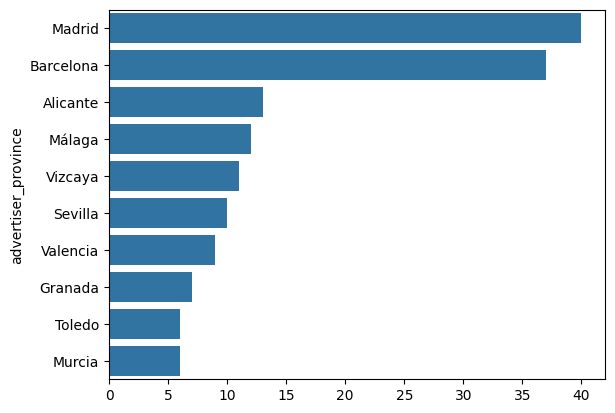

In [282]:
top10 = (
    grupo_gigante["advertiser_province"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top10.values,
    y=top10.index,
    orient = "h"
)
plt.show()


- Solo el 18,70% de los clientes pertenece a un grupo, mientras que el resto son independientes.
- La mayoria de los grupos son pequeños (P50 = 4 clientes)
- El grupo más grande (125) es nacional, opera en 43 provincias de 52 provincias totales y además fuerte concentración en ciudades grandes (coincide que es donde más trafico de clientes hay)

><h4>1.4 Permanencia Clientes<h4>

In [283]:
#Convertir a formato fecha
date_columns = ["min_start_contrato_date", "max_start_contrato_nuevo_date", "contrato_churn_date", "updated_at"]

for col in date_columns:
    if col in df_dim.columns:
        df_dim[col] = pd.to_datetime(df_dim[col], errors = 'coerce')
        
print(df_dim[date_columns].dtypes)

min_start_contrato_date          datetime64[ns]
max_start_contrato_nuevo_date    datetime64[ns]
contrato_churn_date              datetime64[ns]
updated_at                       datetime64[us]
dtype: object


In [397]:
#Fecha antiguedad
from datetime import datetime

today = datetime(2025,6,19)
df_dim["fecha_fin_antiguedad"] = df_dim["contrato_churn_date"].fillna(today)

df_dim["dias_antiguedad"] = (df_dim["fecha_fin_antiguedad"] - df_dim["min_start_contrato_date"] ).dt.days
df_dim["meses_antiguedad"] = df_dim["dias_antiguedad"] / 30

print (f"Antigüedad de clientes (meses) :{df_dim['meses_antiguedad'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])}")

Antigüedad de clientes (meses) :count    7076.000000
mean       21.663369
std        20.229433
min        -0.033333
25%         5.966667
50%        14.250000
75%        33.133333
90%        51.100000
95%        62.166667
max       190.833333
Name: meses_antiguedad, dtype: float64


In [398]:
#Num de clientes que han solicitado la baja
n_churned = df_dim['contrato_churn_date'].notna().sum()
pct_churned = (n_churned /len(df_dim))*100
print(f"Clientes únicos: {df_dim['advertiser_zrive_id'].nunique()}")
print (f"Clientes que han solicitado baja: {n_churned}  ({pct_churned:.1f}%)")

Clientes únicos: 7076
Clientes que han solicitado baja: 3894  (55.0%)


- La antigüedad mediana de los clientes es de 18 meses y el 25% no supera los 7 meses (rotación alta los primeros meses)
- Más de la mitad de los clientes han solicitado baja (55%)

<h4>2. Información General de los datos (DF_WITHDRAWAL)<h4>

In [399]:
print(f"Forma: {df_withdrawals.shape}")
print(f"\nColumnas:")
print(df_withdrawals.columns.tolist())
print(f"\nTipos de datos:")
print(df_withdrawals.dtypes)

Forma: (22668, 7)

Columnas:
['withdrawal_id', 'advertiser_zrive_id', 'withdrawal_status', 'withdrawal_type', 'withdrawal_creation_date', 'withdrawal_effective_date', 'withdrawal_reason']

Tipos de datos:
withdrawal_id                         int64
advertiser_zrive_id                   int64
withdrawal_status                    object
withdrawal_type                      object
withdrawal_creation_date     datetime64[us]
withdrawal_effective_date            object
withdrawal_reason                    object
dtype: object


In [476]:
df_withdrawals['withdrawal_effective_date'] = pd.to_datetime(df_withdrawals['withdrawal_effective_date'])

In [477]:
df_withdrawals.head(10)

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO
5,36,95,Cerrada,TOTAL,2012-06-22 10:40:37,2012-07-01,RAZONES ECONOMICAS
6,49,620,Cerrada,TOTAL,2012-06-26 15:53:04,NaT,RAZONES ECONOMICAS
7,53,443,Cerrada,TOTAL,2012-06-27 08:00:09,NaT,RESULTADOS
8,57,675,Cerrada,TOTAL,2012-06-27 10:55:17,2012-07-01,RESULTADOS
9,58,195,Cerrada,TOTAL,2012-06-27 11:19:15,2012-07-01,RESULTADOS


><h4>2.1 Análisis de Razones de Baja<h4>

In [460]:
n_withdrawals_cond = (
    (df_withdrawals["withdrawal_type"] == "TOTAL")&
    (df_withdrawals["withdrawal_status"] != "Denegada")&
    (~df_withdrawals["withdrawal_reason"].isin([
        "Upselling-cambio de contrato",
        "Cambio a Bundle Online",
        "Cambio de Contrato/propuesta/producto"
    ]))
)

n_withdrawals = df_withdrawals.loc[n_withdrawals_cond].shape[0]
n_withdrawals #Num total de bajas
print(f"Número de bajas reales: {n_withdrawals}")
clientes_churn_real = df_withdrawals.loc[n_withdrawals_cond, "advertiser_zrive_id"].unique()

Número de bajas reales: 15941


In [402]:
#Top 15 razones de baja
reason_dist = (
    df_withdrawals
    .loc[n_withdrawals_cond, "withdrawal_reason"]
    .value_counts(normalize=True)
    .head(15)
) *100
print(reason_dist)


withdrawal_reason
RESULTADOS                           36.139514
MOROSIDAD                            19.936014
RAZONES ECONOMICAS                   14.058089
RATIO RESULTADO-INVERSION            10.162474
FALTA DE USO/TIEMPO                   5.344709
OTROS                                 4.497836
FALTA DE PRODUCTO                     3.594505
CESE DE ACTIVIDAD                     2.860548
Reestructuración cuentas de grupo     1.154256
FIN DE CONTRATO                       0.903331
CORONAVIRUS                           0.633586
No acepta subida                      0.319930
Desconocido                           0.225833
Incidencias de la web                 0.131736
Baja Bundle AS24                      0.037639
Name: proportion, dtype: float64


>La principal causa de baja está relacionada con los resultados, junto con razones economicas y morosidad suma mas del 60%, lo que indica que el churn está muy relacionado con la retorno del servicio

In [447]:
df_clients = df_dim[["advertiser_zrive_id", "meses_antiguedad"]].copy()

In [461]:
df_clients["has_churned"] = df_clients["advertiser_zrive_id"].isin(clientes_churn_real)

In [479]:
df_churn_events = df_withdrawals.loc[n_withdrawals_cond, ["advertiser_zrive_id", "withdrawal_effective_date"]].copy()
first_churn = df_churn_events.sort_values("withdrawal_effective_date").groupby("advertiser_zrive_id").first().reset_index()
first_churn = first_churn.merge(
    df_dim[["advertiser_zrive_id", "min_start_contrato_date"]],
    on="advertiser_zrive_id",
    how="left"
)

first_churn["mes_churn"] = (first_churn["withdrawal_effective_date"] - first_churn["min_start_contrato_date"]).dt.days / 30


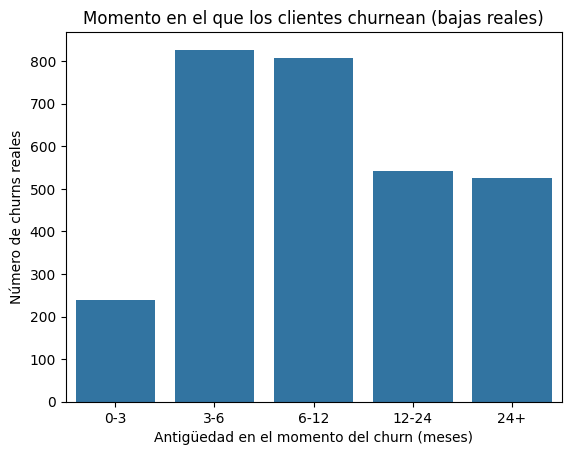

In [480]:
first_churn["antiguedad_bucket"] = pd.cut(
    first_churn["mes_churn"],
    bins=[0, 3, 6, 12, 24, 60],
    labels=["0-3", "3-6", "6-12", "12-24", "24+"]
)

sns.countplot(data=first_churn, x="antiguedad_bucket")
plt.xlabel("Antigüedad en el momento del churn (meses)")
plt.ylabel("Número de churns reales")
plt.title("Momento en el que los clientes churnean (bajas reales)")
plt.show()

>El churn empieza a aumentar claramente a partir de los 3 meses, lo cual tiene bastante sentido porque coincide con el fin de la oferta inicial. Durante el periodo promocional los clientes aguantan, pero cuando pasan a pagar el precio real muchos se dan de baja.

<h4>3. Información General de los datos (DF_SNAPSHOT)<h4>

In [ ]:
print(f"Forma: {df_snapshot.shape}")
print(f"\nColumnas:")
print(df_snapshot.columns.tolist())
print(f"\nTipos de datos:")
print(df_snapshot.dtypes)


Forma: (96829, 23)

Columnas:
['advertiser_zrive_id', 'period_int', 'monthly_contracted_ads', 'monthly_published_ads', 'monthly_unique_published_ads', 'monthly_distinct_ads', 'monthly_oro_ads', 'monthly_plata_ads', 'monthly_destacados_ads', 'monthly_pepitas_ads', 'monthly_shows', 'monthly_visits', 'monthly_leads', 'monthly_total_phone_views', 'monthly_total_calls', 'monthly_total_emails', 'monthly_total_invoice', 'monthly_total_reference_price', 'monthly_unique_calls', 'monthly_unique_emails', 'monthly_unique_leads', 'monthly_avg_ad_price', 'has_active_contract']

Tipos de datos:
advertiser_zrive_id                int64
period_int                         int64
monthly_contracted_ads             int64
monthly_published_ads              int64
monthly_unique_published_ads       int64
monthly_distinct_ads             float64
monthly_oro_ads                    int64
monthly_plata_ads                  int64
monthly_destacados_ads             int64
monthly_pepitas_ads                int64
mon

In [404]:
monthly_payment = df_snapshot["monthly_total_invoice"].describe()
monthly_payment

count    96829.000000
mean       502.381491
std       1048.326272
min      -1833.300000
25%         71.600000
50%        235.000000
75%        545.000000
max      33500.000000
Name: monthly_total_invoice, dtype: float64

In [405]:
df_snapshot[df_snapshot["monthly_total_invoice"] == -1833.3]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
84780,2260,202502,1000,996,996,1049.0,6,6,6,0,...,57,18,16,-1833.3,NaN,15,51,66,309080.72,True


>Aparece un valor negativo en monthly_total_invoice (-1.833€). Al ser casos muy concretos y no representar el comportamiento normal de facturación, tiene sentido excluirlos del análisis para no distorsionar la distribución.

In [406]:
df_snapshot_clean = df_snapshot[df_snapshot["monthly_total_invoice"] >= 0]

In [407]:
print(df_snapshot_clean["has_active_contract"].value_counts())
print()
print("Porcentaje")
print(df_snapshot_clean["has_active_contract"].value_counts(normalize=True)*100)

has_active_contract
True     94208
False     2619
Name: count, dtype: int64

Porcentaje
has_active_contract
True     97.295176
False     2.704824
Name: proportion, dtype: float64


In [408]:
df_snapshot_clean[df_snapshot_clean["has_active_contract"] == False]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
2,3,202301,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
29,41,202301,100,52,52,1.0,0,9,0,0,...,1,0,1,0.0,NaN,0,1,1,31990.00,False
55,76,202301,75,20,20,55.0,6,6,2,0,...,8,5,4,0.0,NaN,2,5,7,31426.32,False
499,699,202301,35,22,22,18.0,5,5,2,0,...,1,0,0,0.0,NaN,0,0,0,24963.64,False
569,792,202301,200,16,16,12.0,15,15,6,0,...,3,0,0,0.0,NaN,0,0,0,22258.33,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96654,6868,202505,14,0,0,NaN,0,0,3,0,...,0,0,0,0.0,NaN,0,0,0,NaN,False
96748,6967,202505,35,15,15,15.0,3,2,9,0,...,6,38,1,0.0,NaN,14,17,31,36123.33,False
96815,7036,202505,14,17,17,17.0,0,2,4,0,...,7,10,2,0.0,NaN,9,6,15,19947.06,False
96827,7066,202505,20,20,20,29.0,3,3,7,0,...,6,24,4,0.0,NaN,17,26,43,9859.33,False


>Para el análisis de pricing solo se tienen en cuenta los meses con contrato activo (has_active_contract = True).
Los meses sin contrato tienen facturación 0 y precios de referencia nulos, por lo que no aportan información útil sobre el valor real del cliente y distorsionan las métricas.

In [409]:
df_active_snapshot = df_snapshot_clean[df_snapshot_clean["has_active_contract"] == True].copy()

In [410]:
main_variables = ['monthly_total_invoice', 'monthly_contracted_ads', 
                   'monthly_published_ads', 'monthly_shows', 'monthly_visits', 'monthly_leads']


df_active_snapshot[main_variables].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

,monthly_total_invoice,monthly_contracted_ads,monthly_published_ads,monthly_shows,monthly_visits,monthly_leads
count,94208.000000,94208.000000,94208.000000,9.420800e+04,94208.000000,94208.000000
mean,516.084772,109.667385,94.806641,6.227466e+04,5201.920793,19.594429
std,1056.812038,496.149974,484.608159,2.161642e+05,14237.624503,52.758418
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,83.300000,6.000000,3.000000,3.872000e+03,362.500000,2.000000
50%,248.300000,20.000000,12.000000,1.595470e+04,1519.200000,6.000000
75%,564.300000,50.000000,39.000000,5.087965e+04,4918.300000,18.000000
90%,1143.500000,150.000000,103.000000,1.282722e+05,11952.500000,43.000000
95%,1723.300000,300.000000,286.000000,2.280083e+05,19953.530000,74.000000
99%,5774.888000,2000.000000,1800.000000,7.332624e+05,56844.175000,224.000000


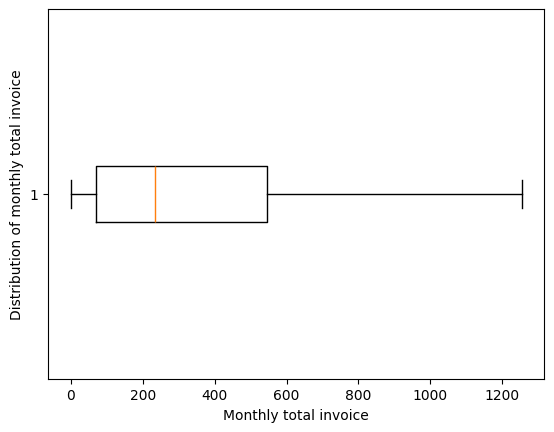

In [486]:
plt.figure()
plt.boxplot(df_snapshot_clean["monthly_total_invoice"], vert = False, showfliers= False)
plt.xlabel("Monthly total invoice")
plt.ylabel("Distribution of monthly total invoice")
plt.show()

In [481]:
df_active_snapshot["price_bucket"] = pd.cut(
    df_active_snapshot["monthly_total_invoice"],
    bins=[0, 100, 250, 500, 1000, 5000, 40000],
    labels=["<100", "100-250", "250-500", "500-1k", "1k-5k", "5k+"]
)

df_active_snapshot["price_bucket"].value_counts(normalize=True)

price_bucket
100-250    0.241117
250-500    0.233941
<100       0.231504
500-1k     0.168413
1k-5k      0.112974
5k+        0.012051
Name: proportion, dtype: float64

In [485]:
df_active_snapshot["price_diff_pct"] = (
    df_active_snapshot["monthly_total_invoice"]
    / df_active_snapshot["monthly_total_reference_price"]
) - 1
df_active_snapshot["price_diff_pct"].describe()


count    84473.000000
mean        -0.483643
std          0.676987
min         -1.000000
25%         -0.702469
50%         -0.500000
75%         -0.229515
max        125.640769
Name: price_diff_pct, dtype: float64

>La mayor parte de los clientes se concentra en un rango de precio mensual bajo: cerca del 70% paga menos de 500€, con un peso muy relevante entre 100–250€ y 250–500€. Al comprarar el precio de tarifa frente a la facturación mensual, los clientes pagan significativamente menos del precio traifa (-50%), esto significa que el precio tarifa está mal planteado

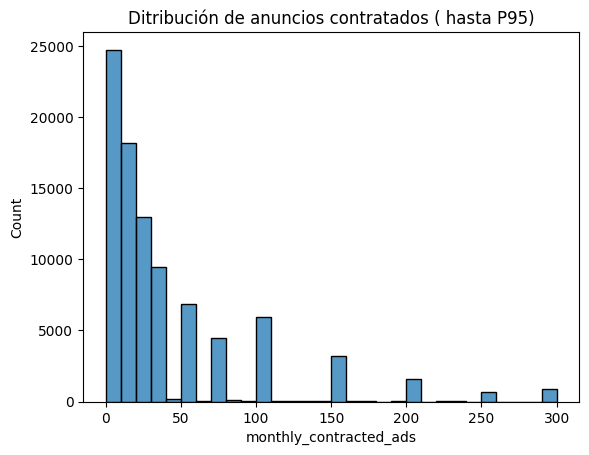

In [411]:
p95 = df_active_snapshot["monthly_contracted_ads"].quantile(0.95)

sns.histplot(
    df_active_snapshot[df_active_snapshot['monthly_contracted_ads'] <= p95]['monthly_contracted_ads'],
    bins=30
)
plt.title("Ditribución de anuncios contratados ( hasta P95)")
plt.show()

In [412]:
df_active_snapshot[df_active_snapshot["monthly_contracted_ads"] == 0]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
174,232,202301,0,15,15,NaN,0,0,0,0,...,29,3,13,257.3,290.0,3,11,14,15550.58,True
194,255,202301,0,20,20,NaN,0,0,0,0,...,2,1,4,162.9,290.0,1,4,5,NaN,True
252,343,202301,0,5,5,NaN,0,0,0,0,...,0,0,0,378.2,633.3,0,0,0,NaN,True
322,450,202301,0,3,3,NaN,0,0,0,0,...,0,0,0,444.3,683.3,0,0,0,NaN,True
381,536,202301,0,43,43,NaN,0,0,0,0,...,7,6,6,444.3,683.3,4,8,12,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10134,4844,202303,0,0,0,NaN,0,0,0,0,...,0,0,0,25.0,383.3,0,0,0,NaN,True
10135,4845,202303,0,1,1,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True
10152,4870,202303,0,48,48,NaN,0,0,0,0,...,3,1,2,83.3,1018.3,1,2,3,NaN,True
10168,4898,202303,0,7,7,NaN,0,0,0,0,...,8,1,2,41.7,383.3,1,3,4,NaN,True


In [413]:
#clientes únicos
print(f"Clientes únicos: {df_active_snapshot['advertiser_zrive_id'].nunique():,}")
#media de clientes por meses
avg_mes = (
    df_snapshot_clean
        .groupby("period_int")["advertiser_zrive_id"]
        .nunique()
        .mean()
)
print(f"Clientes medios por mes {avg_mes:,.1f}")


Clientes únicos: 6,965
Clientes medios por mes 3,338.9


-La mayoría de clientes son pequeños o medianos: lo normal es contratar unos 20 anuncios y publicar alrededor de 12.  
-Los datos están muy descompensados, con unos pocos clientes muy grandes que suben la media, por lo que los percentiles representan mejor la realidad que la media.  
-Aunque hay casi 7.000 clientes distintos en total, en un mes medio hay unos 3.300 activos, lo que muestra bastante rotación de clientes en el tiempo.  
-El recorrido de los anuncios es claro (se muestran, se visitan y luego generan leads), pero los leads no son muchos, así que el valor del servicio está más en el rendimiento que en el volumen.

><h4>Creación columnas nuevas<h4>

In [524]:
#Lead Conversion Rate (% de visitas se convierten en leads)
df_active_snapshot["conversion_rate"] = np.where(
    df_active_snapshot["monthly_visits"] > 0,
    df_active_snapshot["monthly_leads"] / df_active_snapshot["monthly_visits"],
    np.nan
)

#Cost Per Lead (cuanto paga el cliente por cada lead generado)
df_active_snapshot["cost_per_lead"] = np.where(
    df_active_snapshot["monthly_leads"] > 0,
    df_active_snapshot["monthly_total_invoice"] / df_active_snapshot["monthly_leads"],
    np.nan
)

#Ratio de Uso (anuncios publicados vs contratados)
df_active_snapshot["usage_ratio"] = (df_active_snapshot["monthly_published_ads"]/df_active_snapshot["monthly_contracted_ads"].replace(0, np.nan))

In [532]:
df_active_snapshot["usage_ratio"].describe()

count    93866.000000
mean         0.720047
std          0.361489
min          0.000000
25%          0.500000
50%          0.800000
75%          1.000000
max          3.700000
Name: usage_ratio, dtype: float64

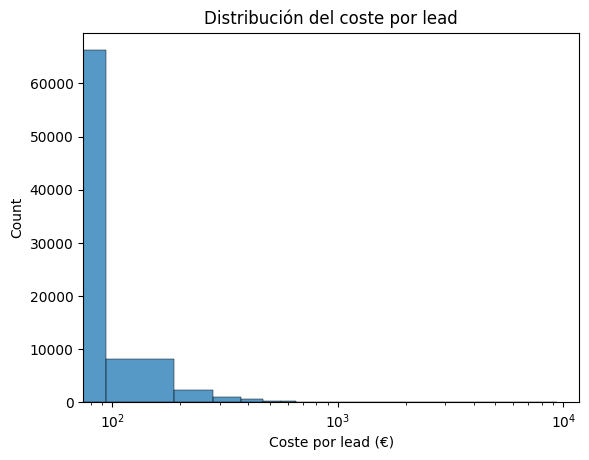

In [492]:
sns.histplot(
    df_active_snapshot["cost_per_lead"], 
    bins = 100
)
plt.xscale("log")
plt.xlabel("Coste por lead (€)")
plt.title("Distribución del coste por lead")
plt.show()

>La distribución del coste por lead está muy sesgada a la derecha. Sin embargo, existe una cola larga de clientes con costes muy elevados, estos clientes están pagando mucho para generar pocos leads. El problema principal es pagar mucho por un rendimiento bajo

In [503]:
df_master = df_active_snapshot.merge(
    df_dim[["advertiser_zrive_id", "advertiser_province", "advertiser_group_id", "meses_antiguedad"]],
    on="advertiser_zrive_id",
    how="left"
)

In [504]:
df_master.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,price_bucket,price_diff,price_diff_pct,conversion_rate,cost_per_lead,usage_ratio,high_cpl,advertiser_province,advertiser_group_id,meses_antiguedad
0,1,202301,75,47,47,56.0,6,6,6,0,...,1k-5k,-702.5,-0.290686,0.003962,95.233333,0.626667,True,Cádiz,NaN,29.633333
1,2,202301,150,31,31,55.0,10,10,4,0,...,250-500,-3350.0,-0.919496,0.002003,73.325000,0.206667,True,Cádiz,100.0,57.600000
2,4,202301,85,79,79,86.0,3,3,1,0,...,1k-5k,-1858.3,-0.614659,0.004640,83.214286,0.929412,True,Vizcaya,NaN,33.100000
3,6,202301,20,20,20,25.0,0,0,1,0,...,250-500,-178.7,-0.346990,0.001811,21.018750,1.000000,False,Vizcaya,NaN,32.766667
4,7,202301,50,42,42,49.0,1,1,1,0,...,500-1k,-243.4,-0.241780,0.003198,50.886667,0.840000,False,Málaga,NaN,33.166667


In [505]:
df_master.columns

Index(['advertiser_zrive_id', 'period_int', 'monthly_contracted_ads',
       'monthly_published_ads', 'monthly_unique_published_ads',
       'monthly_distinct_ads', 'monthly_oro_ads', 'monthly_plata_ads',
       'monthly_destacados_ads', 'monthly_pepitas_ads', 'monthly_shows',
       'monthly_visits', 'monthly_leads', 'monthly_total_phone_views',
       'monthly_total_calls', 'monthly_total_emails', 'monthly_total_invoice',
       'monthly_total_reference_price', 'monthly_unique_calls',
       'monthly_unique_emails', 'monthly_unique_leads', 'monthly_avg_ad_price',
       'has_active_contract', 'price_bucket', 'price_diff', 'price_diff_pct',
       'conversion_rate', 'cost_per_lead', 'usage_ratio', 'high_cpl',
       'advertiser_province', 'advertiser_group_id', 'meses_antiguedad'],
      dtype='object')

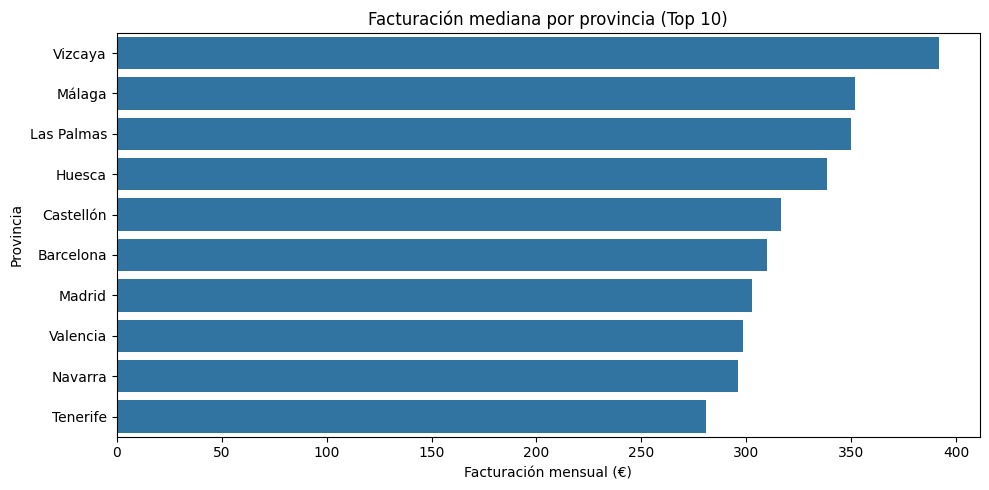

In [506]:
province_stats = (
    df_master
        .groupby('advertiser_province')['monthly_total_invoice']
        .median()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=province_stats.values,
    y=province_stats.index
)

plt.title('Facturación mediana por provincia (Top 10)')
plt.xlabel('Facturación mensual (€)')
plt.ylabel('Provincia')
plt.tight_layout()
plt.show()

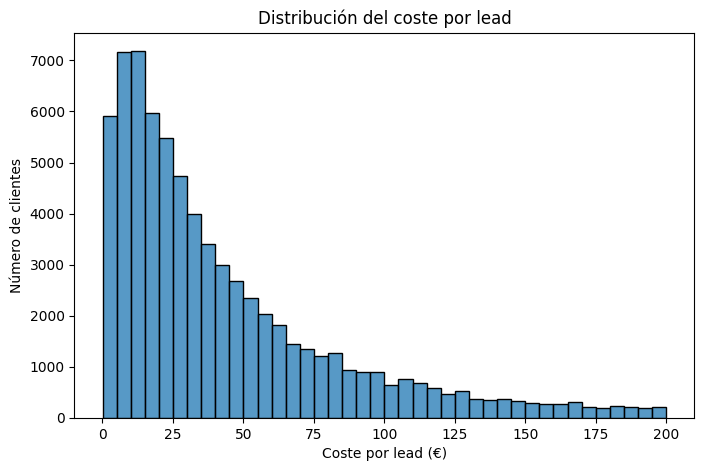

In [536]:
df_cost_plot = df_active_snapshot[
    (df_active_snapshot["cost_per_lead"] > 0) &
    (df_active_snapshot["cost_per_lead"] <= 200)
]

plt.figure(figsize=(8,5))

sns.histplot(
    df_cost_plot["cost_per_lead"],
    bins=40
)

plt.xlabel("Coste por lead (€)")
plt.ylabel("Número de clientes")
plt.title("Distribución del coste por lead")
plt.show()

<h4>CONCLUSIÓN</h4>

- El churn se dispara después de los 3 meses, coincidiendo con el fin de la promoción inicial
- El 55% de clientes (3,894 de 7,076) han solicitado baja al menos una vez
- La causa principal por la que chacer churn es "VALOR PERCIBIDO INSUFICIENTE", no ven suficiente retorno de lo que pagan
- El precio de tarifa no es realista: casi nadie lo paga y la mayoría de clientes está por debajo de 500€/mes.
- Hay diferencias claras por provincia, así que no tiene sentido un precio único para todos.
- Las métricas clave que explican el churn y deben guiar el pricing son:
     - Coste por lead

     - Tasa de conversión

     - Ratio de uso

     - Provincia (valor del tráfico)

     - Antigüedad del cliente

- Solución: Hacer un modelo de ML de segmentación, teniendo en cuenta las variables y categorizando a los tipos de clientes. 